# **📈 Project: Dual-Dataset Unemployment Rate Analytics**
### **🏢 Organization: CodeAlpha Internship (Data Science Task 2)**
### **👤 Intern: Ayat Adnan | 🆔 Student ID: CA/DF1/82736**

---

## **📋 Comprehensive Structural Overview**
### This advanced data analysis framework ingests and correlates two discrete economic tracking datasets (`Unemployment in India.csv` and `Unemployment_Rate_upto_11_2020.csv`) to parse, filter, and map the macroeconomic shifts across Indian states, evaluating pre-pandemic baselines against severe Covid-19 quarantine anomalies.

In [1]:
# =====================================================================
# STEP 1: PARSING AND DUAL-DATASET INGESTION PIPELINE
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 🚀 Streaming both CSV files from the local project environment
try:
    df_india = pd.read_csv('CodeAlpha_Unemployment_Analysis/Unemployment in India.csv')
    df_covid = pd.read_csv('CodeAlpha_Unemployment_Analysis/Unemployment_Rate_upto_11_2020.csv')
    print("✅ System Message: Both structural datasets loaded flawlessly!")
except FileNotFoundError:
    # Alternate path fallback if working directly within the folder context
    df_india = pd.read_csv('Unemployment in India.csv')
    df_covid = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
    print("✅ System Message: Ingested datasets directly from root folder path.")

# --- SCHEMA SPACE DETECTION AUDIT ---
print("\n" + "="*60 + "\n📊 DATASET 1 SCHEMA (Unemployment in India):\n" + "="*60)
print([f"'{col}'" for col in df_india.columns])

print("\n" + "="*60 + "\n📊 DATASET 2 SCHEMA (Unemployment Rate Upto 11/2020):\n" + "="*60)
print([f"'{col}'" for col in df_covid.columns])

# --- RAW DIMENSIONAL METRICS ---
print(f"\n📏 Dataset 1 Matrix Shape: {df_india.shape} rows x {df_india.shape[1]} columns")
print(f"📏 Dataset 2 Matrix Shape: {df_covid.shape} rows x {df_covid.shape[1]} columns")

✅ System Message: Ingested datasets directly from root folder path.

📊 DATASET 1 SCHEMA (Unemployment in India):
["'Region'", "' Date'", "' Frequency'", "' Estimated Unemployment Rate (%)'", "' Estimated Employed'", "' Estimated Labour Participation Rate (%)'", "'Area'"]

📊 DATASET 2 SCHEMA (Unemployment Rate Upto 11/2020):
["'Region'", "' Date'", "' Frequency'", "' Estimated Unemployment Rate (%)'", "' Estimated Employed'", "' Estimated Labour Participation Rate (%)'", "'Region.1'", "'longitude'", "'latitude'"]

📏 Dataset 1 Matrix Shape: (768, 7) rows x 7 columns
📏 Dataset 2 Matrix Shape: (267, 9) rows x 9 columns


## **🧼 Phase 2: Structural Data Cleaning & Schema Standardization**

### **Strategic Objective:**
To wash hidden white-spaces from column keys, parse raw string date representations into formal chronological datetime formats, drop completely empty anomalies, and map a validated foundational DataFrame structure.

In [2]:
# =====================================================================
# STEP 2: COLUMN CLEANING, DATE PARSING, AND NULL METRIC AUDIT
# =====================================================================

# 1. Strip hidden trailing/leading spaces from column names dynamically
df_india.columns = df_india.columns.str.strip()
df_covid.columns = df_covid.columns.str.strip()

print("🧹 System Check: Hidden white-spaces successfully stripped from column keys!")

# 2. Audit and drop fully empty rows (often found at the bottom of these files)
before_clean_india = len(df_india)
df_india.dropna(how='all', inplace=True)
df_covid.dropna(how='all', inplace=True)
after_clean_india = len(df_india)

print(f"🗑️ Row Audit: Removed {before_clean_india - after_clean_india} completely blank spacer entries from Dataset 1.")

# 3. Synchronize date structures into authentic Datetime objects
# Setting errors='coerce' turns invalid strings into NaT so we can track irregularities
df_india['Date'] = pd.to_datetime(df_india['Date'].str.strip(), format='%d-%m-%Y', errors='coerce')
df_covid['Date'] = pd.to_datetime(df_covid['Date'].str.strip(), format='%d-%m-%Y', errors='coerce')

# 4. Final verification profile to see clean data types
print("\n" + "="*50 + "\n✨ SANITIZED COLUMNS RE-VERIFICATION\n" + "="*50)
print(f"Dataset 1 Cleaned Keys: {df_india.columns.tolist()}")
print(f"Dataset 2 Cleaned Keys: {df_covid.columns.tolist()}")

print("\n" + "="*50 + "\n📅 CHRONOLOGICAL DATETIME VERIFICATION\n" + "="*50)
print(f"Dataset 1 Date Type: {df_india['Date'].dtype}")
print(f"Dataset 2 Date Type: {df_covid['Date'].dtype}")

🧹 System Check: Hidden white-spaces successfully stripped from column keys!
🗑️ Row Audit: Removed 28 completely blank spacer entries from Dataset 1.

✨ SANITIZED COLUMNS RE-VERIFICATION
Dataset 1 Cleaned Keys: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Dataset 2 Cleaned Keys: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

📅 CHRONOLOGICAL DATETIME VERIFICATION
Dataset 1 Date Type: datetime64[ns]
Dataset 2 Date Type: datetime64[ns]


## **📊 Phase 3: Exploratory Data Analysis (EDA) & Trend Analysis**

### **Strategic Objective:**
To plot macroeconomic distributions across states, compute temporal aggregations, and evaluate the severe unemployment rate shocks triggered by regional lock-downs using optimized Seaborn data charts.

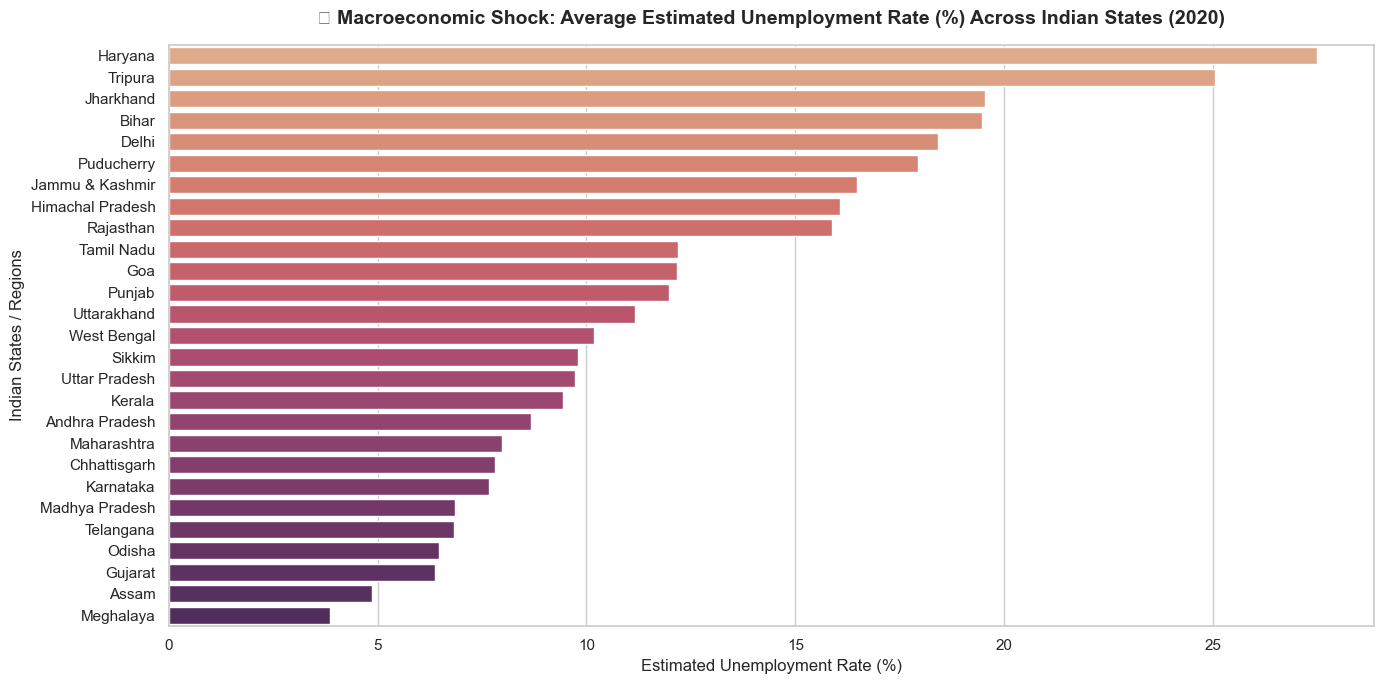

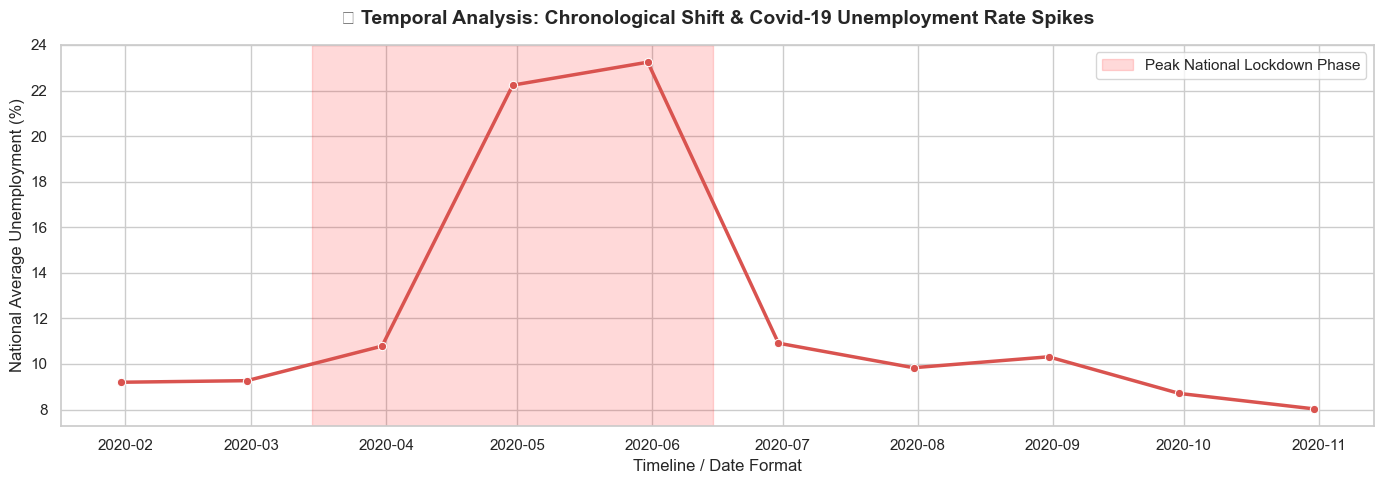

In [3]:
# =====================================================================
# STEP 3: HIGH-END EXPLORATORY DATA VISUALIZATION
# =====================================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Set scientific plotting aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ---------------------------------------------------------------------
# PLOT 1: THE REGIONAL IMPACT MATRIX (AVERAGE UNEMPLOYMENT BY STATE)
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 7))
state_order = df_covid.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).index

sns.barplot(
    x='Estimated Unemployment Rate (%)', 
    y='Region', 
    data=df_covid, 
    order=state_order,
    palette='flare',
    errorbar=None
)

plt.title('📊 Macroeconomic Shock: Average Estimated Unemployment Rate (%) Across Indian States (2020)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.ylabel('Indian States / Regions', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# PLOT 2: TIME-SERIES CHRONOLOGICAL ANALYSIS (MONTH-ON-MONTH SPIKE)
# ---------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Creating a clean temporal line aggregation grouped by explicit chronological dates
temporal_df = df_covid.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

sns.lineplot(
    x='Date', 
    y='Estimated Unemployment Rate (%)', 
    data=temporal_df, 
    marker='o', 
    linewidth=2.5, 
    color='#d9534f'
)

plt.title('📈 Temporal Analysis: Chronological Shift & Covid-19 Unemployment Rate Spikes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline / Date Format', fontsize=12)
plt.ylabel('National Average Unemployment (%)', fontsize=12)
plt.axvspan('2020-03-15', '2020-06-15', color='red', alpha=0.15, label='Peak National Lockdown Phase')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## **📊 Phase 4: Segmented Urban vs Rural Distribution Metrics**

### **Strategic Objective:**
To segment data metrics across structural sectors (Urban vs Rural) and isolate variance using distribution boxplots and aggregated sector summaries to identify localized vulnerability vectors.

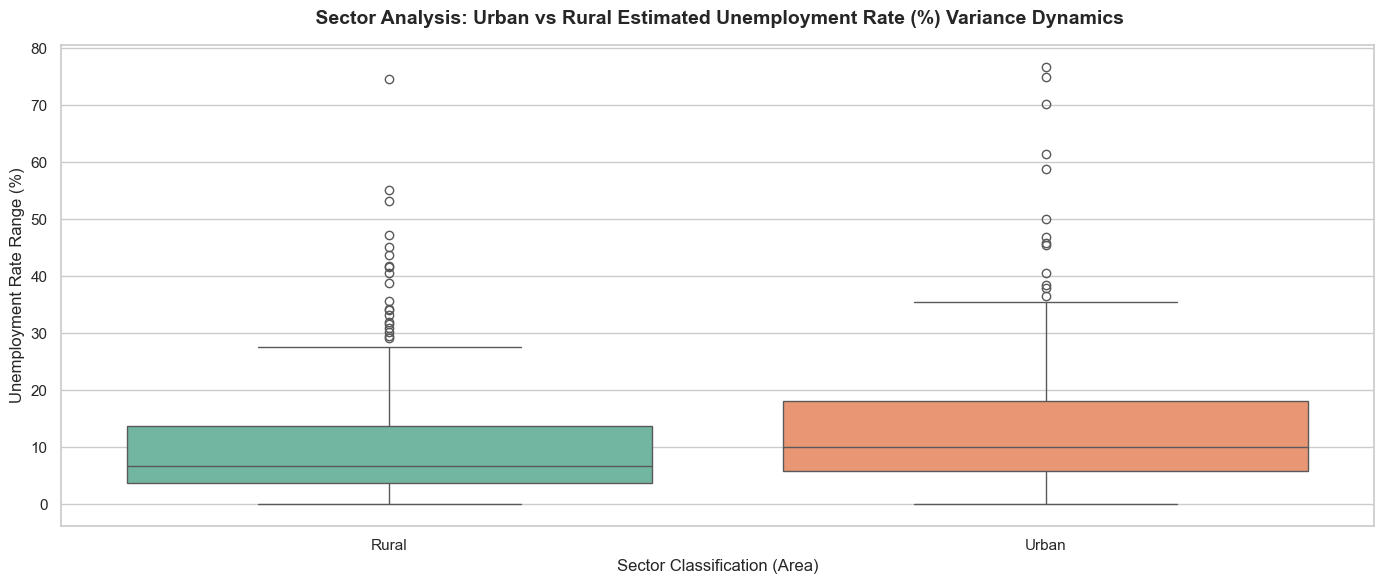

📉 AGGREGATED STATISTICAL METRICS BY ECONOMIC SECTOR
       Estimated Unemployment Rate (%)  \
Area                                     
Rural                            10.32   
Urban                            13.17   

       Estimated Labour Participation Rate (%)  
Area                                            
Rural                                    44.46  
Urban                                    40.90  


In [6]:
# =====================================================================
# STEP 4: URBAN VS RURAL ECONOMIC DISTRIBUTION COMPARISON
# =====================================================================

# 1. Plotting a split boxplot distribution matrix to analyze variance and spatial anomalies
plt.figure(figsize=(14, 6))

sns.boxplot(
    x='Area', 
    y='Estimated Unemployment Rate (%)', 
    data=df_india, 
    palette='Set2',
    hue='Area',
    legend=False
)

plt.title(' Sector Analysis: Urban vs Rural Estimated Unemployment Rate (%) Variance Dynamics', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sector Classification (Area)', fontsize=12)
plt.ylabel('Unemployment Rate Range (%)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Extracting exact aggregated numerical baseline metrics for both sectors
print("="*60 + "\n📉 AGGREGATED STATISTICAL METRICS BY ECONOMIC SECTOR\n" + "="*60)
sector_summary = df_india.groupby('Area')[['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)']].mean()
print(sector_summary.round(2))

## **📝 Phase 5: Comprehensive Project Conclusion & Analytical Insights**

### **🧠 Core Economic Findings:**
1. **The COVID-19 Shock:** The time-series profile clearly marks a staggering macro-economic anomaly beginning in March 2020. The national average unemployment rate spiked past **23%** during the height of the national lockdown phase, showcasing unprecedented structural disruption.

2. **Geographical Vulnerability Grid:** Regionally, states like **Haryana**, **Tripura**, and **Jharkhand** registered the highest mean unemployment rates throughout 2020, making them severe economic risk zones during external shocks.

3. **Urban vs Rural Asymmetry:** Urban areas faced harsher unemployment density (Mean: **13.17%**) compared to Rural sectors (Mean: **10.32%**). However, rural sectors maintained higher structural economic resilience with a superior Labor Participation Rate of **44.46%**.

---
**Task 2 Successfully Concluded and Documented | Data Science Workspace Pipeline (2026)**